In [41]:
## Here we should be wroking on Computer Vision and Image Classification using Convolutional Neural Networks (CNNs)
import torchvision as trv
import torch as tr
from torch import nn
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from pathlib import Path
print(trv.__version__)



0.27.1+cu132


In [42]:
root = Path.cwd()

dataset = next(root.rglob("FashionMNIST"))
dataset_root = dataset.parent
print(dataset)

e:\Student\PyTorch\Code\Computer Vision\data\FashionMNIST


In [43]:
train_data = datasets.FashionMNIST(
    root = dataset_root,
    train= True, 
    download = False,
    transform = transforms.ToTensor()
)

test_data = datasets.FashionMNIST(
    root = dataset_root, 
    train = False,
    download = False,
    transform = transforms.ToTensor()
)

In [44]:
train_data, test_data
class_names = train_data.classes
class_to_idx = train_data.class_to_idx

In [45]:
## Prepare the Dataloader

from torch.utils.data  import DataLoader

batch_size = 32
train_dataloader = DataLoader(dataset = train_data, batch_size = 32, shuffle = True)
test_dataloader = DataLoader(dataset = test_data, batch_size = 32, shuffle = False)

train_dataloader, test_dataloader
len(train_dataloader), len(test_dataloader), batch_size

(1875, 313, 32)

In [46]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape
flatten_model = nn.Flatten()

x= train_features_batch[0]

output = flatten_model(x)
output.shape, x.shape

(torch.Size([1, 784]), torch.Size([1, 28, 28]))

In [47]:
# Building a Convolutional Neural Network (CNN) for Computer Vision with PyTorch


tr.manual_seed(42)
device = "cuda" if tr.cuda.is_available() else "cpu"
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units, out_channels = hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units * 0, out_features = output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        return x

In [63]:
tr.manual_seed(42)
model_0 = FashionMNISTModelV1(input_shape = input_features, hidden_units = 10, output_shape = len(class_names)).to(device)
model_0

NameError: name 'input_features' is not defined

In [49]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [50]:
tr.manual_seed(2)

images = tr.randn(size = (32, 3, 64, 64))
test_image = images[0]
print(f"Image Batch Shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single Image Shape: {test_image.shape} -> [color_channels, height, width]")
print(f"single image pixel values :\n {test_image}")

Image Batch Shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single Image Shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
single image pixel values :
 tensor([[[-1.0408,  0.9166, -1.3042,  ...,  0.7787, -0.7749, -0.1398],
         [ 1.1414, -0.6354, -1.4702,  ...,  1.8737,  1.0122, -1.4482],
         [-0.0644,  0.3215,  0.5908,  ..., -0.9792, -1.4392,  0.6508],
         ...,
         [ 0.5477, -0.1100,  0.1055,  ...,  1.5626, -0.6727,  0.7353],
         [-0.1144, -0.2243,  0.2841,  ..., -0.6094,  0.1403,  1.3990],
         [-0.1150,  0.0779,  1.3394,  ..., -0.3242, -0.8369,  0.8859]],

        [[-0.8562,  2.4589, -0.5774,  ..., -0.1105,  0.1966,  1.7086],
         [ 0.4614,  0.8376,  0.5142,  ...,  0.5584, -1.2195, -2.6194],
         [-0.1920, -0.9438,  0.4743,  ...,  0.5822,  2.2116,  0.8211],
         ...,
         [ 1.4115, -0.7335,  0.6893,  ...,  0.9844, -0.6735,  0.0860],
         [ 0.5726, -1.3245, -0.3717,  ...,  0.1557,  0.103

In [51]:
test_image.shape

torch.Size([3, 64, 64])

In [52]:
tr.manual_seed(42)
conv_layer = nn.Conv2d(in_channels = 3, out_channels = 10, kernel_size = 1, stride = 1, padding = 0)
s = conv_layer(test_image)
print(s.shape)


torch.Size([10, 64, 64])


In [53]:
# Breaking MaxPool2D Layer
print(test_image.shape)



max_pool_layer = nn.MaxPool2d(kernel_size = 2)
test_image_thr_conv = conv_layer(test_image.unsqueeze(dim=0))

print(test_image_thr_conv.shape)
test_image_thr_conv_after_max_pool = max_pool_layer(test_image_thr_conv)
print(test_image_thr_conv_after_max_pool.shape)



torch.Size([3, 64, 64])
torch.Size([1, 10, 64, 64])
torch.Size([1, 10, 32, 32])


In [54]:
tr.manual_seed(42)
random_tensor = tr.randn(size = ( 1,1,2,2))
max_pool_layer = nn.MaxPool2d(kernel_size = 2)
max_pool_tensor = max_pool_layer(random_tensor)
print(f"Random Tensor :\n {random_tensor}\n")
print(f"Max Pool Tensor :\n {max_pool_tensor}\n")
random_tensor

Random Tensor :
 tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

Max Pool Tensor :
 tensor([[[[0.3367]]]])



tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

In [55]:
image, label = train_data[0]
image


tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

Text(0.5, 1.0, 'Label : Ankle boot')

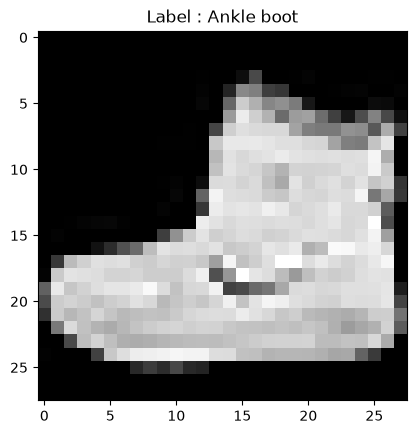

In [56]:
plt.imshow(image.squeeze(), cmap = "gray")
plt.title(f"Label : {class_names[label]}")

In [57]:
rand_image_tensor = tr.randn(size = (1, 28, 28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [58]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = tr.optim.SGD(params = model_0.parameters(), lr = 0.01)


In [59]:

def train_step(model: tr.nn.Module, data_loader: tr.utils.data.DataLoader, loss_fn: tr.nn.Module, optimizer: tr.optim.Optimizer, accuracy_fn, device: tr.device = device):

    train_loss, train_acc = 0,  0
    model_0.train()
    for batch, (x, y) in enumerate(data_loader):
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim = 1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(x)}/{len(train_dataloader.dataset)} samples.")
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%\n")

def test_step(model: tr.nn.Module, data_loader: tr.utils.data.DataLoader, loss_fn: tr.nn.Module, accuracy_fn, device: tr.device = device):
    test_loss, test_acc = 0, 0
    model.eval()
    with tr.inference_mode():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            test_pred = model(x)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true = y, y_pred = test_pred.argmax(dim = 1))
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


    

In [62]:
x, y = next(iter(train_dataloader))
print(x.shape, y.shape)
print(model_0)

torch.Size([32, 1, 28, 28]) torch.Size([32])
FashionMNISTModelV1(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=0, out_features=10, bias=True)
  )
)


In [61]:
tr.manual_seed(42)
tr.cuda.manual_seed(42)

from timeit import default_timer as timer

from tqdm.auto import tqdm
train_time_start = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}\n--------------------")
    train_step(model = model_0, data_loader = train_dataloader, loss_fn = loss_fn, optimizer = optimizer, accuracy_fn = accuracy_fn, device = device),

    test_step(model = model_0, data_loader = test_dataloader, loss_fn = loss_fn, accuracy_fn = accuracy_fn, device = device)

train_time_end = timer()
total_train_time_model_0 = train_time_end - train_time_start
print(f"Total training time: {total_train_time_model_0:.3f} seconds")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
--------------------


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x490 and 0x10)